In [1]:
# Load data and summarise VSRS metrics

import pandas as pd

fdf_vsrs = pd.read_csv("fdf_all_vsrs_filtered.csv") # engineer internship/placement filtered
fdf_all = pd.read_csv("fdf_all_vsrs_applied.csv")
egfdf_vsrs = pd.read_csv("egfdf_all_vsrs_filtered.csv") # engineer graduate filtered
egfdf_all = pd.read_csv("egfdf_all_vsrs_applied.csv")
efdf_vsrs = pd.read_csv("efdf_all_vsrs_filtered.csv") # engineer filtered
efdf_all = pd.read_csv("efdf_all_vsrs_applied.csv")
ipfdf_vsrs = pd.read_csv("ipfdf_all_vsrs_filtered.csv") # internship/placement filtered
ipfdf_all = pd.read_csv("ipfdf_all_vsrs_applied.csv")
gfdf_vsrs = pd.read_csv("gfdf_all_vsrs_filtered.csv") # graduate filtered
gfdf_all = pd.read_csv("gfdf_all_vsrs_applied.csv")
ufdf_vsrs = pd.read_csv("ufdf_all_vsrs_filtered.csv") # unfiltered
ufdf_all = pd.read_csv("ufdf_all_vsrs_applied.csv")

fdf_title = "Engineering Internship/Placement"
egfdf_title = "Engineering Graduate*" # *sample
efdf_title = "Engineering*"
ipfdf_title = "Internship/Placement*"
gfdf_title = "Graduate*"
ufdf_title = "General*"

print(f"{fdf_title} jobs with VSRS at {round(len(fdf_vsrs)/len(fdf_all)*100,2)}%: {len(fdf_vsrs)} of {len(fdf_all)}")
print(f"{egfdf_title} jobs with VSRS at {round(len(egfdf_vsrs)/len(egfdf_all)*100,2)}%: {len(egfdf_vsrs)} of {len(egfdf_all)}")
print(f"{efdf_title} jobs with VSRS at {round(len(efdf_vsrs)/len(efdf_all)*100,2)}%: {len(efdf_vsrs)} of {len(efdf_all)}")
print(f"{ipfdf_title} jobs with VSRS at {round(len(ipfdf_vsrs)/len(ipfdf_all)*100,2)}%: {len(ipfdf_vsrs)} of {len(ipfdf_all)}")
print(f"{gfdf_title} jobs with VSRS at {round(len(gfdf_vsrs)/len(gfdf_all)*100,2)}%: {len(gfdf_vsrs)} of {len(gfdf_all)}")
print(f"{ufdf_title} jobs with VSRS at {round(len(ufdf_vsrs)/len(ufdf_all)*100,2)}%: {len(ufdf_vsrs)} of {len(ufdf_all)}")

Engineering Internship/Placement jobs with VSRS at 26.17%: 1640 of 6267
Engineering Graduate* jobs with VSRS at 25.46%: 3047 of 11966
Engineering* jobs with VSRS at 9.05%: 1086 of 12000
Internship/Placement* jobs with VSRS at 17.24%: 2069 of 12000
Graduate* jobs with VSRS at 17.02%: 2042 of 12000
General* jobs with VSRS at 9.51%: 1141 of 12000


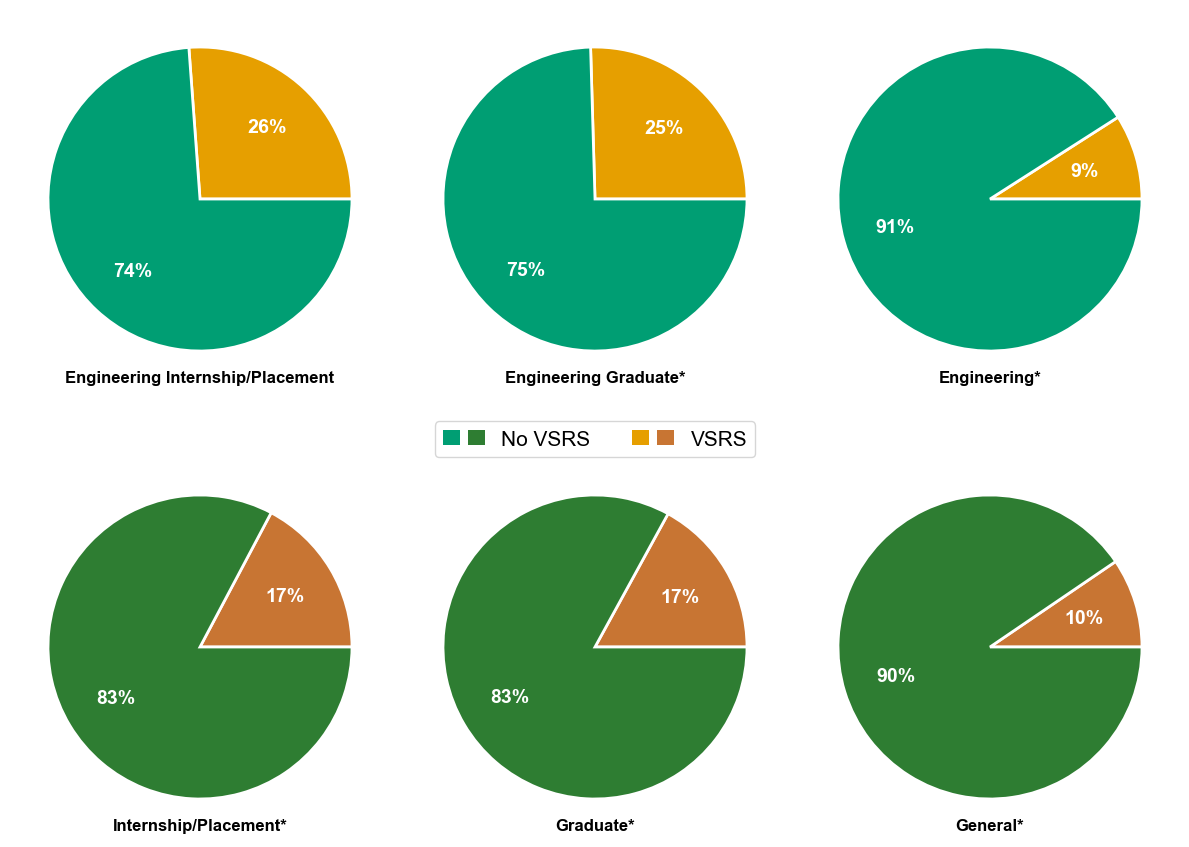

In [2]:
# Create VSRS pie charts

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

plt.rcParams["font.family"] = "Arial"

labels = ['VSRS', 'No VSRS']

# Define colours
engineering_colours = ["#E69F00", "#009E73"]
non_engineering_colours = ["#C87533", "#2E7D32"]

fig, axes = plt.subplots(2, 3, figsize=(12, 12))

# Calculate VSRS and non-VSRS counts for each filter
f   = [len(fdf_vsrs)  , len(fdf_all)-len(fdf_vsrs)    ]
egf = [len(egfdf_vsrs), len(egfdf_all)-len(egfdf_vsrs)]
ef  = [len(efdf_vsrs) , len(efdf_all)-len(efdf_vsrs)  ]
ipf = [len(ipfdf_vsrs), len(ipfdf_all)-len(ipfdf_vsrs)]
gf  = [len(gfdf_vsrs) , len(gfdf_all)-len(gfdf_vsrs)  ]
uf  = [len(ufdf_vsrs) , len(ufdf_all)-len(ufdf_vsrs)  ]

# Organise the data, title and axes placement
pie_data = [
    (f,   fdf_title,   (0, 0), engineering_colours),
    (egf, egfdf_title, (0, 1), engineering_colours),
    (ef,  efdf_title,  (0, 2), engineering_colours),
    (ipf, ipfdf_title, (1, 0), non_engineering_colours),
    (gf,  gfdf_title,  (1, 1), non_engineering_colours),
    (uf,  ufdf_title,  (1, 2), non_engineering_colours)
]

# Create pie charts
for values, title, position, colors in pie_data:
    ax = axes[position]
    ax.pie(
        values,
        colors=colors,
        autopct='%1.0f%%',
        pctdistance=0.65,
        textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax.text(
        0.5, 0.05,
        title,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=12,
        fontweight='bold'
    )

# Shared legend
legend = [
    ((Patch(facecolor="#009E73"), Patch(facecolor="#2E7D32")), "No VSRS"),
    ((Patch(facecolor="#E69F00"), Patch(facecolor="#C87533")), "VSRS")
]
fig.legend(
    handles=[item[0] for item in legend],
    labels=[item[1] for item in legend],
    handler_map={tuple: HandlerTuple(ndivide=2)},
    loc="upper center",
    ncol=2,
    fontsize=15,
    frameon=True,
    bbox_to_anchor=(0.5, 0.45)
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.savefig('filter_pie.svg', format='svg', bbox_inches='tight')

In [3]:
# Calculate quarterly VSRS percentages

import pandas as pd

# Load dataset
fdf_vsrs = pd.read_csv("fdf_all_vsrs_filtered.csv") # engineer internship/placement filtered
fdf_all = pd.read_csv("fdf_all_vsrs_applied.csv")
egfdf_vsrs = pd.read_csv("egfdf_all_vsrs_filtered.csv") # engineer graduate filtered
egfdf_all = pd.read_csv("egfdf_all_vsrs_applied.csv")
efdf_vsrs = pd.read_csv("efdf_all_vsrs_filtered.csv") # engineer filtered
efdf_all = pd.read_csv("efdf_all_vsrs_applied.csv")
ipfdf_vsrs = pd.read_csv("ipfdf_all_vsrs_filtered.csv") # internship/placement filtered
ipfdf_all = pd.read_csv("ipfdf_all_vsrs_applied.csv")
gfdf_vsrs = pd.read_csv("gfdf_all_vsrs_filtered.csv") # graduate filtered
gfdf_all = pd.read_csv("gfdf_all_vsrs_applied.csv")
ufdf_vsrs = pd.read_csv("ufdf_all_vsrs_filtered.csv") # unfiltered
ufdf_all = pd.read_csv("ufdf_all_vsrs_applied.csv")

fdf_title = "Engineering Internship/Placement"
egfdf_title = "Engineering Graduate*" # *sample
efdf_title = "Engineering*"
ipfdf_title = "Internship/Placement*"
gfdf_title = "Graduate*"
ufdf_title = "General*"

# Count VSRS and total jobs for each quarter

# VSRS jobs
fdf_quarter = fdf_vsrs["quarter"].value_counts().sort_index()
egfdf_quarter = egfdf_vsrs["quarter"].value_counts().sort_index()
efdf_quarter = efdf_vsrs["quarter"].value_counts().sort_index()
ipfdf_quarter = ipfdf_vsrs["quarter"].value_counts().sort_index()
gfdf_quarter = gfdf_vsrs["quarter"].value_counts().sort_index()
ufdf_quarter = ufdf_vsrs["quarter"].value_counts().sort_index()

# Total jobs
fdf_quarter_all = fdf_all["quarter"].value_counts().sort_index()
egfdf_quarter_all = egfdf_all["quarter"].value_counts().sort_index()
efdf_quarter_all = efdf_all["quarter"].value_counts().sort_index()
ipfdf_quarter_all = ipfdf_all["quarter"].value_counts().sort_index()
gfdf_quarter_all = gfdf_all["quarter"].value_counts().sort_index()
ufdf_quarter_all = ufdf_all["quarter"].value_counts().sort_index()

# Calculate the percentage of jobs containing VSRS for each quarter
fdf_percentage = (fdf_quarter / fdf_quarter_all * 100).tolist()
egfdf_percentage = (egfdf_quarter / egfdf_quarter_all * 100).tolist()
efdf_percentage = (efdf_quarter / efdf_quarter_all * 100).tolist()
ipfdf_percentage = (ipfdf_quarter / ipfdf_quarter_all * 100).tolist()
gfdf_percentage = (gfdf_quarter / gfdf_quarter_all * 100).tolist()
ufdf_percentage = (ufdf_quarter / ufdf_quarter_all * 100).tolist()

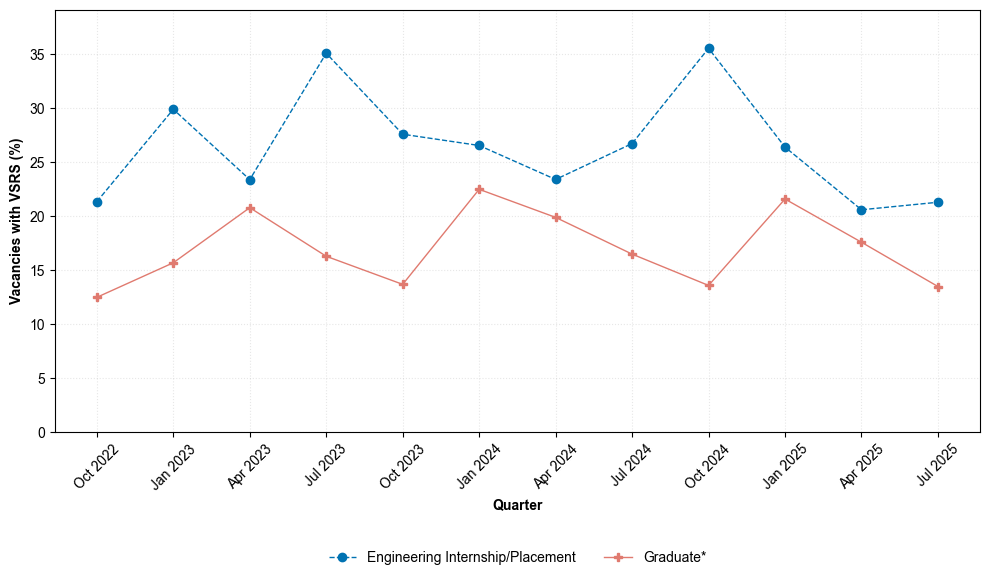

In [4]:
# Plot quarterly VSRS trends

import matplotlib.pyplot as plt

labels = [
    "Oct 2022", "Jan 2023", "Apr 2023", "Jul 2023",
    "Oct 2023", "Jan 2024", "Apr 2024", "Jul 2024",
    "Oct 2024", "Jan 2025", "Apr 2025", "Jul 2025"
]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each filter's percentage of VSRS
plot_data = [
    (fdf_percentage,   fdf_title,   "#0072B2", "o", "--"),   # Engineering
    #(ipfdf_percentage, ipfdf_title, "#56B4E9", "D", "-" ),   # Non-engineering
    #(egfdf_percentage, egfdf_title, "#C44536", "s", "--"),   # Engineering
    (gfdf_percentage,  gfdf_title,  "#E07A6F", "P", "-" ),   # Non-engineering
    #(efdf_percentage,  efdf_title,  "#6A3D9A", "^", "--"),   # Engineering
    #(ufdf_percentage,  ufdf_title,  "#CAB2D6", "X", "-" )    # Non-engineering
]
for percentage, title, color, marker, linestyle in plot_data:
    ax.plot(
        labels,
        percentage,
        color=color,
        linestyle=linestyle,
        marker=marker,
        linewidth=1,
        markersize=6,
        label=title
    )

ax.set_xlabel(
    "Quarter",
    fontweight="bold"
)

ax.set_ylabel(
    "Vacancies with VSRS (%)",
    fontweight="bold"
)

ax.set_ylim(
    0,
    max(
        max(fdf_percentage),
        #max(ufdf_percentage),
        #max(efdf_percentage),
        #max(ipfdf_percentage),
        #max(egfdf_percentage),
        max(gfdf_percentage)
    ) * 1.1
)

# Format x-axis labels
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)

# Gridlines
ax.grid(
    True,
    alpha=0.3,
    linestyle=":"
)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3, # Change column depending on number of data variables
    frameon=False
)

fig.tight_layout()

plt.savefig(
    "filter_line.svg",
    format="svg",
    bbox_inches="tight"
)
